# 06 — Multilingual Transformer Fine-Tuning

We fine-tune two pretrained transformer backbones on the two tasks and compare them against the hybrid system from `05_hybrid_feature_engineering.ipynb`.

**Backbones compared:**

- `xlm-roberta-base` — general multilingual RoBERTa.
- `Musixmatch/umberto-commoncrawl-cased-v1` — Italian RoBERTa trained on Italian CommonCrawl.

Topic uses subject + body; priority uses the body. Training: `max_len=256`, batch size 16, AdamW with `lr=2e-5`, up to 5 epochs (small dataset), on an RTX 3060 (6 GB). We use the same stratified + grouped-by-subject splits as `03/04/05` so the numbers are directly comparable.


## 1 — Imports and configuration

Pinned seeds across `random`, `numpy`, `torch` for reproducibility. fp16 enabled to fit `xlm-roberta-base` and `umberto` (both ~125 M params) comfortably on a 6 GB GPU.


In [1]:
import gc
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path("../data/processed/frozen_dataset.csv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOPIC_ORDER = ["administrative", "course-exam", "event", "deadline-action", "advertisement"]
PRIORITY_ORDER = ["High", "Medium", "Low"]
TASK_LABELS = {"topic": TOPIC_ORDER, "priority": PRIORITY_ORDER}

BACKBONES = {
    "xlm-r":   "xlm-roberta-base",
    "umberto": "Musixmatch/umberto-commoncrawl-cased-v1",
}
TEXT_FIELDS = ["text_subject", "text_body", "text_subject_body"]

MAX_LEN     = 256
BATCH_SIZE  = 16
LR          = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS_SWEEP = 2
EPOCHS_MAIN  = 5
WARMUP_RATIO = 0.1

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
print("Data   :", DATA_PATH.resolve())


Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
Data   : D:\UniGe\3\NLP\NLP-project\Preprocessing\frozen_dataset.csv


## 2 — Load the frozen dataset

Same artifact as `03/04/05`. We only need the text fields and the two label columns.


In [2]:
df = pd.read_csv(DATA_PATH)
for col in TEXT_FIELDS:
    df[col] = df[col].fillna("").astype(str)

print(f"Shape   : {df.shape}")
print("Topic counts:")
print(df["topic"].value_counts().reindex(TOPIC_ORDER).to_string())
print()
print("Priority counts:")
print(df["priority"].value_counts().reindex(PRIORITY_ORDER).to_string())


Shape   : (919, 8)
Topic counts:
topic
administrative     159
course-exam        267
event              189
deadline-action    197
advertisement      107

Priority counts:
priority
High      272
Medium    309
Low       338


## 3 — Splits (identical to 03 / 04 / 05)

Two pre-computed splits per task so transformer numbers are directly comparable to every previous notebook:

- **Stratified** (`train_test_split(..., stratify=y)`, `seed=42`) — the optimistic split.
- **Grouped-by-subject** (`GroupShuffleSplit(... groups=text_subject)`, `seed=42`) — the honest split. Subject overlap verified to be 0.


In [3]:
indices = np.arange(len(df))

idx_train_topic, idx_test_topic = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=df["topic"].values,
)
idx_train_priority, idx_test_priority = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=df["priority"].values,
)
SPLITS_STRAT = {
    "topic":    (idx_train_topic,    idx_test_topic),
    "priority": (idx_train_priority, idx_test_priority),
}
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
SPLITS_GROUPED = next(gss.split(indices, groups=df["text_subject"].values))

print("Stratified:")
for task, (tr, te) in SPLITS_STRAT.items():
    print(f"  {task:<8} -> train={len(tr):>4} test={len(te):>4}")
overlap = len(set(df.loc[SPLITS_GROUPED[0], "text_subject"]) &
              set(df.loc[SPLITS_GROUPED[1], "text_subject"]))
print(f"\nGrouped-by-subject: train={len(SPLITS_GROUPED[0]):>4} test={len(SPLITS_GROUPED[1]):>4} "
      f"(overlap={overlap}, must be 0)")


Stratified:
  topic    -> train= 735 test= 184
  priority -> train= 735 test= 184

Grouped-by-subject: train= 727 test= 192 (overlap=0, must be 0)


## 4 — Helpers: tokenizer cache, Dataset, training loop, evaluation, recorder

`EmailDataset` holds raw text + integer label (tokenized in the `collate_fn`). `train_one_config(...)` runs the AdamW + warmup loop with fp16, evaluates after each epoch, and returns the best-epoch metrics and predictions. `record(...)` appends one results row.


In [4]:
TOKENIZERS: dict = {}


def get_tokenizer(backbone_id: str):
    if backbone_id not in TOKENIZERS:
        TOKENIZERS[backbone_id] = AutoTokenizer.from_pretrained(backbone_id, use_fast=True)
    return TOKENIZERS[backbone_id]


class EmailDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = np.asarray(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        return self.texts[i], int(self.labels[i])


def make_collate(tokenizer):
    def _collate(batch):
        texts, labels = zip(*batch)
        enc = tokenizer(list(texts), padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt")
        enc["labels"] = torch.tensor(labels, dtype=torch.long)
        return enc
    return _collate


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            with autocast(enabled=torch.cuda.is_available()):
                logits = model(input_ids=batch["input_ids"],
                               attention_mask=batch["attention_mask"]).logits
            all_preds.append(logits.argmax(dim=-1).cpu().numpy())
            all_labels.append(batch["labels"].cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return y_true, y_pred, {
        "accuracy":        accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall":    r,
        "macro_f1":        f,
        "weighted_f1":     f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def train_one_config(backbone_id: str, task: str, field: str,
                     weighted: bool, epochs: int,
                     idx_train, idx_test, split_type: str,
                     verbose: bool = True):
    labels_list = TASK_LABELS[task]
    label_to_id = {lab: i for i, lab in enumerate(labels_list)}
    y_train = np.array([label_to_id[v] for v in df.loc[idx_train, task].values])
    y_test  = np.array([label_to_id[v] for v in df.loc[idx_test,  task].values])
    X_train = df.loc[idx_train, field].values
    X_test  = df.loc[idx_test,  field].values

    tokenizer = get_tokenizer(backbone_id)
    train_ds = EmailDataset(X_train, y_train)
    test_ds  = EmailDataset(X_test,  y_test)
    collate = make_collate(tokenizer)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2, shuffle=False,
                              collate_fn=collate, num_workers=0)

    model = AutoModelForSequenceClassification.from_pretrained(
        backbone_id, num_labels=len(labels_list),
    ).to(DEVICE)

    no_decay = {"bias", "LayerNorm.weight"}
    grouped_params = [
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": WEIGHT_DECAY},
        {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer = AdamW(grouped_params, lr=LR)
    total_steps = max(1, len(train_loader) * epochs)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps,
    )

    if weighted:
        cw = compute_class_weight("balanced", classes=np.arange(len(labels_list)), y=y_train)
        class_weights = torch.tensor(cw, dtype=torch.float, device=DEVICE)
    else:
        class_weights = None
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    scaler = GradScaler(enabled=torch.cuda.is_available())

    best_metrics, best_preds, best_true, best_epoch = None, None, None, -1
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=torch.cuda.is_available()):
                out = model(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"])
                loss = loss_fn(out.logits, batch["labels"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running += loss.item()
        y_true, y_pred, metrics = evaluate_model(model, test_loader)
        if best_metrics is None or metrics["macro_f1"] > best_metrics["macro_f1"]:
            best_metrics, best_preds, best_true, best_epoch = metrics, y_pred, y_true, epoch
        if verbose:
            print(f"   epoch {epoch}/{epochs} | train loss={running/len(train_loader):.3f} | "
                  f"test macroF1={metrics['macro_f1']:.3f}")

    del model, optimizer, scheduler, scaler
    free_cuda()

    y_true_str = np.array([labels_list[i] for i in best_true])
    y_pred_str = np.array([labels_list[i] for i in best_preds])
    return best_metrics, y_true_str, y_pred_str, best_epoch


RESULTS: list[dict] = []
PREDS: dict = {}


def record(task, split_type, backbone, field, weighted, epochs, best_epoch, metrics):
    row = {
        "task":       task,
        "split_type": split_type,
        "backbone":   backbone,
        "input_field": field,
        "weighted":   weighted,
        "epochs":     epochs,
        "best_epoch": best_epoch,
        **{k: round(v, 4) for k, v in metrics.items()},
    }
    RESULTS.append(row)
    return row


print("Helpers ready.")


Helpers ready.


## 5 — Stage A: input field sweep

The report states the input fields directly (topic = subject + body, priority = body). This short 2-epoch sweep over the three fields confirms that choice; the resulting `BEST_FIELD` matches the report.


In [5]:
# === APPENDIX (optional, beyond report scope): input-field sweep to confirm the fields the report states directly ===
SWEEP_RESULTS = []
for task in ("topic", "priority"):
    print(f"\n=== Field sweep — task: {task} ===")
    idx_tr, idx_te = SPLITS_STRAT[task]
    for field in TEXT_FIELDS:
        print(f" [{field}]")
        metrics, y_true, y_pred, be = train_one_config(
            BACKBONES["xlm-r"], task, field,
            weighted=True, epochs=EPOCHS_SWEEP,
            idx_train=idx_tr, idx_test=idx_te,
            split_type="stratified", verbose=True,
        )
        record(task, "stratified_sweep", "xlm-r", field, True, EPOCHS_SWEEP, be, metrics)
        PREDS[(task, "xlm-r", field, True, "stratified_sweep")] = (y_true, y_pred)
        SWEEP_RESULTS.append({"task": task, "field": field, **metrics})
        print(f"   -> best test macroF1={metrics['macro_f1']:.3f}")

sweep_df = pd.DataFrame(SWEEP_RESULTS)
sweep_df[["task", "field", "macro_f1", "accuracy", "weighted_f1"]]



=== Field sweep — task: topic ===
 [text_subject]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch 1/2 | train loss=1.045 | test macroF1=0.580


   epoch 2/2 | train loss=0.850 | test macroF1=0.577


   -> best test macroF1=0.580


,task,field,macro_f1,accuracy,weighted_f1
0,topic,text_subject,0.491768,0.565217,0.507908
1,topic,text_body,0.566426,0.614130,0.589012
2,topic,text_subject_body,0.686253,0.722826,0.689055
3,priority,text_subject,0.545722,0.586957,0.550448
4,priority,text_body,0.610725,0.630435,0.615095
5,priority,text_subject_body,0.579862,0.592391,0.584109


In [6]:
BEST_FIELD = {
    t: sweep_df[sweep_df["task"] == t].sort_values("macro_f1", ascending=False).iloc[0]["field"]
    for t in ("topic", "priority")
}
print("Best field per task (xlm-r, 2-epoch sweep):")
for t, f in BEST_FIELD.items():
    print(f"  {t:<8} -> {f}")


Best field per task (xlm-r, 2-epoch sweep):
  topic    -> text_subject_body
  priority -> text_body


## 6 — Stage B: main matrix (5 epochs)

For each task, fine-tune both backbones (XLM-R and Umberto) on the chosen input field, for 5 epochs. The weighted/unweighted comparison is an optional class-weighting ablation beyond the report.


In [7]:
# The report compares the two backbones. The weighted=False rows are an APPENDIX
# (optional, beyond report scope) class-weighting ablation.
MAIN_CONFIGS = [
    ("xlm-r",   True),
    ("xlm-r",   False),   # appendix
    ("umberto", True),
    ("umberto", False),   # appendix
]

for task in ("topic", "priority"):
    field = BEST_FIELD[task]
    idx_tr, idx_te = SPLITS_STRAT[task]
    print(f"\n=== MAIN — task: {task} | field: {field} ===")
    for bb_name, weighted in MAIN_CONFIGS:
        print(f"\n [{bb_name} | weighted={weighted}]")
        metrics, y_true, y_pred, be = train_one_config(
            BACKBONES[bb_name], task, field,
            weighted=weighted, epochs=EPOCHS_MAIN,
            idx_train=idx_tr, idx_test=idx_te,
            split_type="stratified", verbose=True,
        )
        record(task, "stratified", bb_name, field, weighted, EPOCHS_MAIN, be, metrics)
        PREDS[(task, bb_name, field, weighted, "stratified")] = (y_true, y_pred)
        print(f"  -> macroF1={metrics['macro_f1']:.3f}  acc={metrics['accuracy']:.3f}  "
              f"(best epoch {be})")



=== MAIN — task: topic | field: text_subject_body ===

 [xlm-r | weighted=True]


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch 1/5 | train loss=1.501 | test macroF1=0.690


   epoch 2/5 | train loss=0.938 | test macroF1=0.774


   epoch 3/5 | train loss=0.644 | test macroF1=0.782


...

   epoch 1/5 | train loss=1.028 | test macroF1=0.520


   epoch 2/5 | train loss=0.813 | test macroF1=0.656


   epoch 3/5 | train loss=0.623 | test macroF1=0.742


   epoch 4/5 | train loss=0.514 | test macroF1=0.711


   epoch 5/5 | train loss=0.458 | test macroF1=0.740
  -> macroF1=0.742  acc=0.755  (best epoch 3)


### Stratified results table


In [8]:
results_df = pd.DataFrame(RESULTS)
table_main = (results_df[results_df["split_type"] == "stratified"]
              .sort_values(["task", "macro_f1"], ascending=[True, False])
              .reset_index(drop=True))
table_main[["task", "backbone", "input_field", "weighted",
            "best_epoch", "accuracy", "macro_precision", "macro_recall",
            "macro_f1", "weighted_f1"]]


,task,backbone,input_field,weighted,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,priority,xlm-r,text_body,False,3,0.7717,0.7652,0.7707,0.7608,0.7637
1,priority,umberto,text_body,True,4,0.7554,0.7510,0.7533,0.7517,0.7555
2,priority,umberto,text_body,False,3,0.7554,0.7450,0.7525,0.7423,0.7454
3,priority,xlm-r,text_body,True,5,0.7174,0.7113,0.7202,0.7100,0.7124
4,topic,umberto,text_subject_body,False,4,0.8696,0.8836,0.8499,0.8581,0.8680
5,topic,xlm-r,text_subject_body,True,4,0.8641,0.8846,0.8435,0.8530,0.8629
6,topic,xlm-r,text_subject_body,False,5,0.8641,0.8684,0.8344,0.8424,0.8598
7,topic,umberto,text_subject_body,True,4,0.8370,0.8468,0.8266,0.8284,0.8375


## 7 — Stage C: grouped-by-subject re-evaluation

For each (task, backbone) pair we re-train the best stratified config under the `GroupShuffleSplit` that prevents identical cleaned subjects from appearing on both sides. This is the headline metric: the gap between stratified and grouped tells us how much of the score was template memorization vs real generalization.


In [9]:
def best_stratified_row(task: str, backbone: str):
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")
                     & (results_df["backbone"] == backbone)]
    return sub.sort_values("macro_f1", ascending=False).iloc[0]


for task in ("topic", "priority"):
    field = BEST_FIELD[task]
    idx_tr_g, idx_te_g = SPLITS_GROUPED
    print(f"\n=== GROUPED — task: {task} | field: {field} ===")
    for bb_name in ("xlm-r", "umberto"):
        best_row = best_stratified_row(task, bb_name)
        weighted = bool(best_row["weighted"])
        print(f"\n [{bb_name} | weighted={weighted}]")
        metrics, y_true, y_pred, be = train_one_config(
            BACKBONES[bb_name], task, field,
            weighted=weighted, epochs=EPOCHS_MAIN,
            idx_train=idx_tr_g, idx_test=idx_te_g,
            split_type="grouped_subject", verbose=True,
        )
        record(task, "grouped_subject", bb_name, field, weighted, EPOCHS_MAIN, be, metrics)
        PREDS[(task, bb_name, field, weighted, "grouped_subject")] = (y_true, y_pred)
        print(f"  -> macroF1={metrics['macro_f1']:.3f}  acc={metrics['accuracy']:.3f}  "
              f"(best epoch {be})")



=== GROUPED — task: topic | field: text_subject_body ===

 [xlm-r | weighted=True]


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch 1/5 | train loss=1.544 | test macroF1=0.384


   epoch 2/5 | train loss=1.129 | test macroF1=0.653


   epoch 3/5 | train loss=0.708 | test macroF1=0.717


...

   epoch 1/5 | train loss=1.028 | test macroF1=0.538


   epoch 2/5 | train loss=0.799 | test macroF1=0.732


   epoch 3/5 | train loss=0.640 | test macroF1=0.774


   epoch 4/5 | train loss=0.537 | test macroF1=0.786


   epoch 5/5 | train loss=0.477 | test macroF1=0.803
  -> macroF1=0.803  acc=0.802  (best epoch 5)


In [10]:
results_df = pd.DataFrame(RESULTS)

rows = []
for task in ("topic", "priority"):
    for bb in ("xlm-r", "umberto"):
        s = results_df[(results_df["task"] == task)
                       & (results_df["split_type"] == "stratified")
                       & (results_df["backbone"] == bb)].sort_values("macro_f1", ascending=False).iloc[0]
        g = results_df[(results_df["task"] == task)
                       & (results_df["split_type"] == "grouped_subject")
                       & (results_df["backbone"] == bb)].iloc[0]
        rows.append({
            "task": task, "backbone": bb,
            "stratified macroF1": s["macro_f1"],
            "grouped macroF1":    g["macro_f1"],
            "drop": round(g["macro_f1"] - s["macro_f1"], 4),
        })
strat_vs_grp = pd.DataFrame(rows)
strat_vs_grp


,task,backbone,stratified macroF1,grouped macroF1,drop
0,topic,xlm-r,0.8530,0.7833,-0.0697
1,topic,umberto,0.8581,0.8147,-0.0434
2,priority,xlm-r,0.7608,0.7436,-0.0172
3,priority,umberto,0.7517,0.8033,0.0516


## 8 — Plots

Confusion matrices for the best model of each task (report figures). The two bar charts below (main matrix and stratified-vs-grouped) are optional.


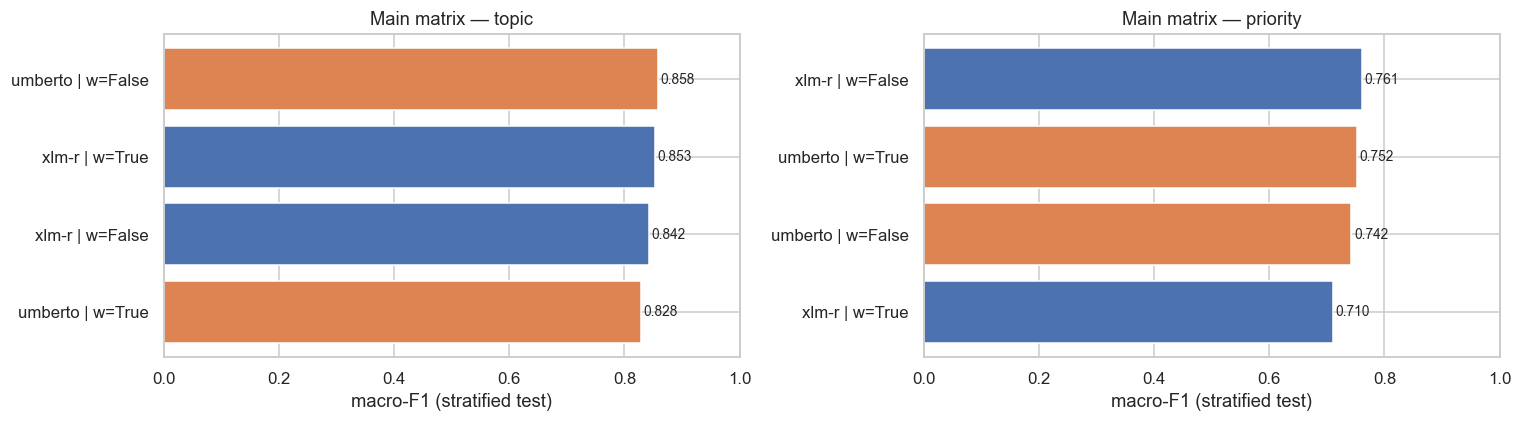

In [11]:
# === APPENDIX (optional, beyond report scope): main-matrix macro-F1 bar chart ===
def plot_main(task: str, ax):
    sub = (results_df[(results_df["task"] == task)
                      & (results_df["split_type"] == "stratified")]
           .sort_values("macro_f1", ascending=True))
    labels = sub["backbone"] + " | w=" + sub["weighted"].astype(str)
    colors = ["#4C72B0" if b == "xlm-r" else "#DD8452" for b in sub["backbone"]]
    ax.barh(labels, sub["macro_f1"], color=colors)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("macro-F1 (stratified test)")
    ax.set_title(f"Main matrix — {task}")
    for y, v in enumerate(sub["macro_f1"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_main("topic", axes[0])
plot_main("priority", axes[1])
plt.tight_layout()
plt.show()


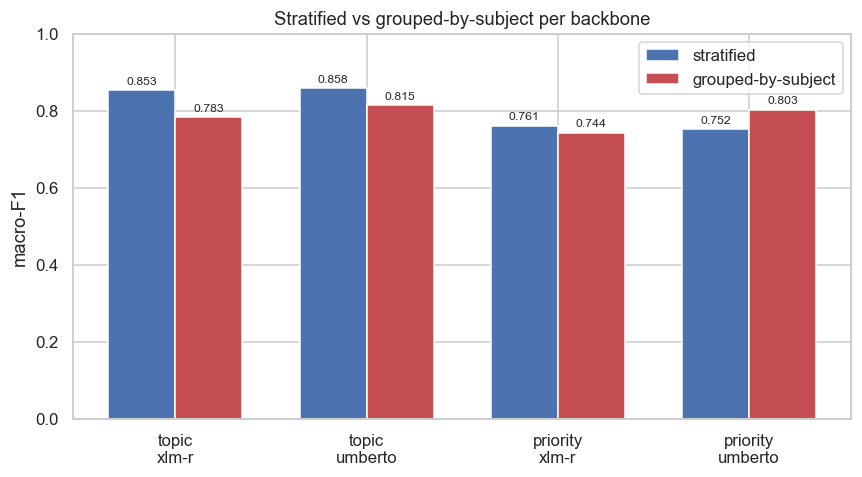

In [12]:
# === APPENDIX (optional, beyond report scope): stratified vs grouped-by-subject bar chart ===
fig, ax = plt.subplots(figsize=(8, 4.5))
tasks_bb = [(t, b) for t in ("topic", "priority") for b in ("xlm-r", "umberto")]
labels = [f"{t}\n{b}" for t, b in tasks_bb]
strat = [strat_vs_grp[(strat_vs_grp["task"] == t) & (strat_vs_grp["backbone"] == b)]
         ["stratified macroF1"].iloc[0] for t, b in tasks_bb]
grp   = [strat_vs_grp[(strat_vs_grp["task"] == t) & (strat_vs_grp["backbone"] == b)]
         ["grouped macroF1"].iloc[0]    for t, b in tasks_bb]
x = np.arange(len(tasks_bb)); w = 0.35
b1 = ax.bar(x - w/2, strat, w, color="#4C72B0", label="stratified")
b2 = ax.bar(x + w/2, grp,   w, color="#C44E52", label="grouped-by-subject")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel("macro-F1")
ax.set_title("Stratified vs grouped-by-subject per backbone")
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


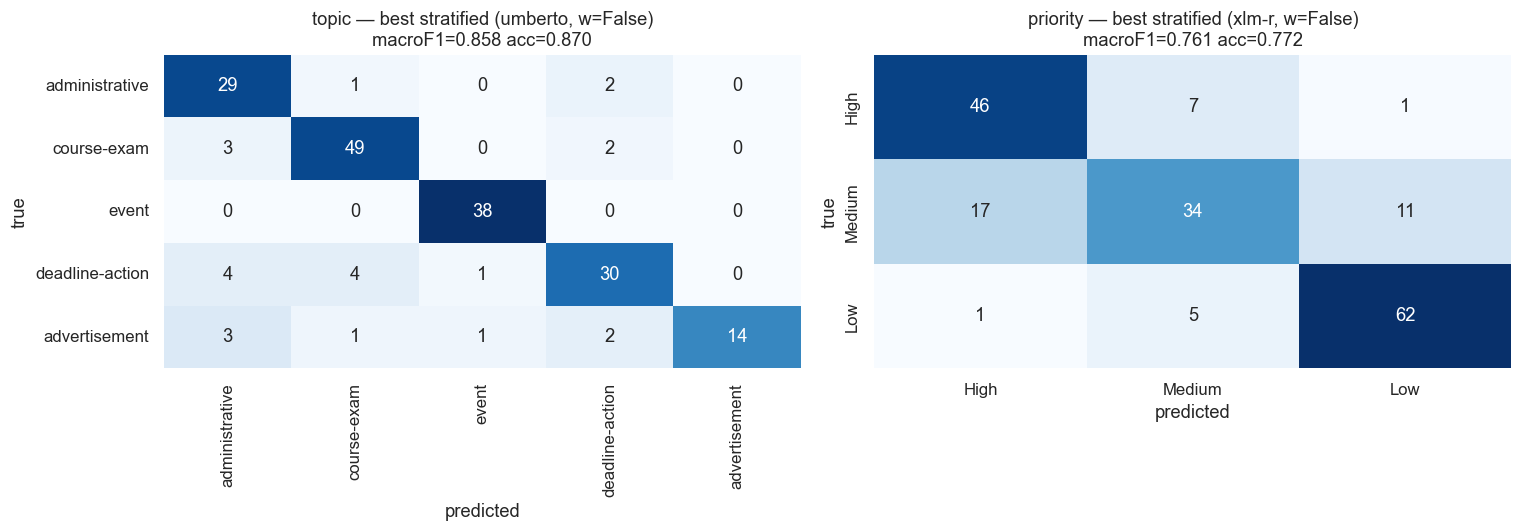

In [13]:
def confusion_for(task: str, ax):
    row = best_stratified_row(task, "xlm-r")
    row_u = best_stratified_row(task, "umberto")
    # show the winner between xlm-r and umberto
    best = row if row["macro_f1"] >= row_u["macro_f1"] else row_u
    bb_name = best["backbone"]
    field = best["input_field"]
    weighted = bool(best["weighted"])
    y_true, y_pred = PREDS[(task, bb_name, field, weighted, "stratified")]
    labels = TASK_LABELS[task]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{task} — best stratified ({bb_name}, w={weighted})\n"
                 f"macroF1={best['macro_f1']:.3f} acc={best['accuracy']:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confusion_for("topic",    axes[0])
confusion_for("priority", axes[1])
plt.tight_layout()
plt.show()


## 9 — Per-class classification report (best stratified model per task)


In [14]:
for task in ("topic", "priority"):
    rx = best_stratified_row(task, "xlm-r")
    ru = best_stratified_row(task, "umberto")
    best = rx if rx["macro_f1"] >= ru["macro_f1"] else ru
    bb_name, field, weighted = best["backbone"], best["input_field"], bool(best["weighted"])
    y_true, y_pred = PREDS[(task, bb_name, field, weighted, "stratified")]
    print(f"=== {task.upper()} | {bb_name} | {field} | weighted={weighted} ===")
    print(classification_report(y_true, y_pred, labels=TASK_LABELS[task], zero_division=0))


=== TOPIC | umberto | text_subject_body | weighted=False ===
                 precision    recall  f1-score   support

 administrative       0.74      0.91      0.82        32
    course-exam       0.89      0.91      0.90        54
          event       0.95      1.00      0.97        38
deadline-action       0.83      0.77      0.80        39
  advertisement       1.00      0.67      0.80        21

       accuracy                           0.87       184
      macro avg       0.88      0.85      0.86       184
   weighted avg       0.88      0.87      0.87       184

=== PRIORITY | xlm-r | text_body | weighted=False ===
              precision    recall  f1-score   support

        High       0.72      0.85      0.78        54
      Medium       0.74      0.55      0.63        62
         Low       0.84      0.91      0.87        68

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.76       184
weighted avg       0.77      0.77      0.76

## 10 — Error analysis

For each task we list the misclassified test rows of the best stratified model and tally confusion types. For priority we also bucket errors by adjacency (`High↔Medium`, `Medium↔Low`, `High↔Low`) and count `Medium`-involvement — the headline diagnostic from `03/04/05` (baseline = 42 / 44 errors involving Medium).


In [15]:
def errors_for(task: str):
    rx = best_stratified_row(task, "xlm-r")
    ru = best_stratified_row(task, "umberto")
    best = rx if rx["macro_f1"] >= ru["macro_f1"] else ru
    bb_name, field, weighted = best["backbone"], best["input_field"], bool(best["weighted"])
    idx_tr, idx_te = SPLITS_STRAT[task]
    y_true, y_pred = PREDS[(task, bb_name, field, weighted, "stratified")]
    err = y_true != y_pred
    err_idx = np.array(idx_te)[err]
    out = pd.DataFrame({
        "id": df.loc[err_idx, "id"].values,
        "text_subject": df.loc[err_idx, "text_subject"].values,
        f"true_{task}": y_true[err],
        f"pred_{task}": y_pred[err],
        ("priority" if task == "topic" else "topic"):
            df.loc[err_idx, "priority" if task == "topic" else "topic"].values,
    })
    return out, bb_name


topic_err, topic_bb = errors_for("topic")
print(f"Topic errors ({topic_bb}): {len(topic_err)} / 184 "
      f"({len(topic_err)/184*100:.1f}%)")
print("\nConfusion types:")
print((topic_err["true_topic"] + " -> " + topic_err["pred_topic"]).value_counts().to_string())

print()
priority_err, priority_bb = errors_for("priority")
print(f"Priority errors ({priority_bb}): {len(priority_err)} / 184 "
      f"({len(priority_err)/184*100:.1f}%)")
print("\nConfusion types:")
print((priority_err["true_priority"] + " -> " + priority_err["pred_priority"]).value_counts().to_string())


def bucket(t, p):
    pair = frozenset([t, p])
    if pair == frozenset(["High", "Medium"]): return "High <-> Medium"
    if pair == frozenset(["Medium", "Low"]):  return "Medium <-> Low"
    if pair == frozenset(["High", "Low"]):    return "High <-> Low"
    return "same"


buckets = priority_err.apply(lambda r: bucket(r["true_priority"], r["pred_priority"]), axis=1)
print("\nAdjacency buckets:")
print(buckets.value_counts().to_string())
medium = priority_err.apply(
    lambda r: "Medium" in (r["true_priority"], r["pred_priority"]), axis=1).sum()
print(f"\nErrors involving Medium: {medium}  (03/04/05 baseline: 42-44)")


Topic errors (umberto): 24 / 184 (13.0%)

Confusion types:
deadline-action -> course-exam       4
deadline-action -> administrative    4
advertisement -> administrative      3
course-exam -> administrative        3
advertisement -> deadline-action     2
course-exam -> deadline-action       2
administrative -> deadline-action    2
advertisement -> course-exam         1
deadline-action -> event             1
advertisement -> event               1
administrative -> course-exam        1

Priority errors (xlm-r): 42 / 184 (22.8%)

Confusion types:
Medium -> High    17
Medium -> Low     11
High -> Medium     7
Low -> Medium      5
Low -> High        1
High -> Low        1

Adjacency buckets:
High <-> Medium    24
Medium <-> Low     16
High <-> Low        2

Errors involving Medium: 40  (03/04/05 baseline: 42-44)


## 11 — Final conclusion


In [16]:
def summarize(task: str):
    rx = best_stratified_row(task, "xlm-r")
    ru = best_stratified_row(task, "umberto")
    best = rx if rx["macro_f1"] >= ru["macro_f1"] else ru
    gx = results_df[(results_df["task"] == task)
                    & (results_df["split_type"] == "grouped_subject")
                    & (results_df["backbone"] == "xlm-r")].iloc[0]
    gu = results_df[(results_df["task"] == task)
                    & (results_df["split_type"] == "grouped_subject")
                    & (results_df["backbone"] == "umberto")].iloc[0]
    g_best = gx if gx["macro_f1"] >= gu["macro_f1"] else gu
    return best, g_best


print("Transformer fine-tuning completed.\n")
for task in ("topic", "priority"):
    best, g_best = summarize(task)
    print(f"--- {task.upper()} ---")
    print(f"  Best stratified : {best['backbone']:<8} | weighted={bool(best['weighted'])} "
          f"| macroF1={best['macro_f1']:.3f} acc={best['accuracy']:.3f} "
          f"(epoch {best['best_epoch']}/{best['epochs']})")
    print(f"  Best grouped    : {g_best['backbone']:<8} | weighted={bool(g_best['weighted'])} "
          f"| macroF1={g_best['macro_f1']:.3f} acc={g_best['accuracy']:.3f}")
    print()

# Decide reference backbone: best grouped macro-F1 across tasks.
ranked = []
for task in ("topic", "priority"):
    _, g_best = summarize(task)
    ranked.append((task, g_best["backbone"], g_best["macro_f1"]))
print("Per-task best backbone under grouped split:")
for t, b, f in ranked:
    print(f"  {t:<8} -> {b}  macroF1={f:.3f}")

print()
print("Reference target for any future model: the grouped macro-F1 of these backbones.")


Transformer fine-tuning completed.

--- TOPIC ---
  Best stratified : umberto  | weighted=False | macroF1=0.858 acc=0.870 (epoch 4/5)
  Best grouped    : umberto  | weighted=False | macroF1=0.815 acc=0.807

--- PRIORITY ---
  Best stratified : xlm-r    | weighted=False | macroF1=0.761 acc=0.772 (epoch 3/5)
  Best grouped    : umberto  | weighted=True | macroF1=0.803 acc=0.802

Per-task best backbone under grouped split:
  topic    -> umberto  macroF1=0.815
  priority -> umberto  macroF1=0.803

Reference target for any future model: the grouped macro-F1 of these backbones.
